# TCS STOCK PRICE PREDICTOR


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np


## Fetch Data

In [2]:
def fetch_data(ticker):
    df = yf.Ticker(ticker).history(period="max")
    df = df.loc["2000-01-01":].copy()
    return df

data = fetch_data("TCS.NS")

In [3]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2002-08-12 00:00:00+05:30,25.194087,26.023589,25.194087,25.828413,212976,0.0,0.0
2002-08-13 00:00:00+05:30,25.860931,26.275682,25.291665,25.478708,153576,0.0,0.0
2002-08-14 00:00:00+05:30,25.535642,25.535642,23.242312,23.722124,822776,0.0,0.0
2002-08-15 00:00:00+05:30,23.722124,23.722124,23.722124,23.722124,0,0.0,0.0
2002-08-16 00:00:00+05:30,23.600136,24.722402,23.258575,23.665194,811856,0.0,0.0
...,...,...,...,...,...,...,...
2026-02-17 00:00:00+05:30,2716.000000,2760.000000,2695.199951,2717.399902,4209118,0.0,0.0
2026-02-18 00:00:00+05:30,2730.000000,2730.000000,2657.300049,2694.899902,2950820,0.0,0.0
2026-02-19 00:00:00+05:30,2708.000000,2748.699951,2666.600098,2677.899902,3238849,0.0,0.0


In [4]:
data.sample(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-11-03 00:00:00+05:30,376.684739,386.756898,375.788638,377.365784,2217878,0.0,0.0
2024-05-30 00:00:00+05:30,3567.855852,3584.292268,3509.714019,3529.220703,2919230,0.0,0.0
2025-02-17 00:00:00+05:30,3727.674957,3802.586096,3727.384931,3774.071533,1799806,0.0,0.0
2016-02-01 00:00:00+05:30,945.742521,954.384709,933.046095,950.330566,1495274,0.0,0.0
2006-09-15 00:00:00+05:30,168.230839,168.230839,165.360630,166.356079,2359700,0.0,0.0
2024-06-06 00:00:00+05:30,3571.634110,3627.272539,3534.321350,3618.298584,4328036,0.0,0.0
2014-12-29 00:00:00+05:30,974.292466,985.538765,973.903992,980.080688,778920,0.0,0.0
2014-09-18 00:00:00+05:30,1004.776518,1028.076733,1000.628252,1024.393677,1483078,0.0,0.0
2026-01-21 00:00:00+05:30,3100.000000,3138.500000,3082.000000,3122.600098,2015150,0.0,0.0


In [5]:
data["Dividends"].unique

<bound method Series.unique of Date
2002-08-12 00:00:00+05:30    0.0
2002-08-13 00:00:00+05:30    0.0
2002-08-14 00:00:00+05:30    0.0
2002-08-15 00:00:00+05:30    0.0
2002-08-16 00:00:00+05:30    0.0
                            ... 
2026-02-17 00:00:00+05:30    0.0
2026-02-18 00:00:00+05:30    0.0
2026-02-19 00:00:00+05:30    0.0
2026-02-20 00:00:00+05:30    0.0
2026-02-23 00:00:00+05:30    0.0
Name: Dividends, Length: 5843, dtype: float64>

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

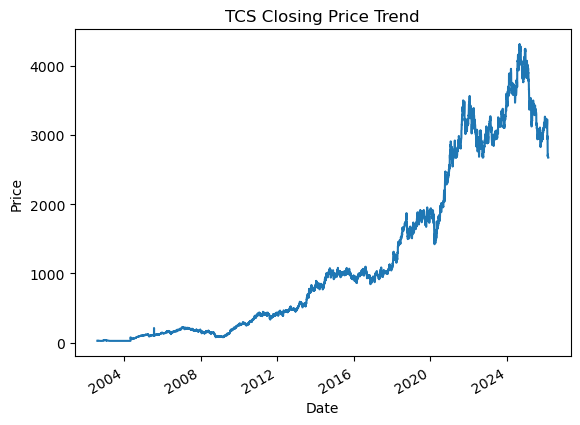

In [7]:
data["Close"].plot(title="TCS Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

### Create Target Variable

In [8]:
data["Next_Close"] = data["Close"].shift(-1)


In [9]:
data["Target"] = (data["Next_Close"] > data["Close"]).astype(int)

In [10]:
# Daily return feature
data["Daily_Return"] = data["Close"].pct_change()

In [11]:
# from sklearn.model_selection import train_test_split

# basic_features = ["Open", "High", "Low", "Close", "Volume"]

# X = data[basic_features]
# y = data["Target"]

# # Random split leaks future information in time-series
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, shuffle=True, random_state=42
# )

# model.fit(X_train, y_train)
# naive_preds = model.predict(X_test)

# print("Naive Precision:",
#       precision_score(y_test, naive_preds))

In [12]:
def build_features(df, windows):
    features = []

    for w in windows:
        moving_avg = df["Close"].rolling(w).mean()

        df[f"MA_Ratio_{w}"] = df["Close"] / moving_avg
        df[f"Momentum_{w}"] = df["Target"].shift(1).rolling(w).sum()

        features.extend([f"MA_Ratio_{w}", f"Momentum_{w}"])

    features.append("Daily_Return")

    return df, features

data, feature_columns = build_features(data, [3, 10, 50, 200, 800])

In [13]:
data.dropna(inplace=True)

## Model 

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
model = RandomForestClassifier(n_estimators=300,max_depth=6,min_samples_split=40,random_state=42)

In [15]:
def walk_forward_validation(df, features, model, start_train=2000, step=200):

    all_results = []

    for split in range(start_train, len(df), step):

        train_data = df.iloc[:split]
        test_data = df.iloc[split:split + step]

        if len(test_data) == 0:
            break

        model.fit(train_data[features], train_data["Target"])

        probs = model.predict_proba(test_data[features])[:, 1]

        preds = np.where(probs > 0.65, 1, 0)

        batch_results = pd.DataFrame({
            "Actual": test_data["Target"],
            "Predicted": preds
        }, index=test_data.index)

        all_results.append(batch_results)

    return pd.concat(all_results)


In [16]:
results = walk_forward_validation(data, feature_columns, model)


In [17]:
print("Prediction Distribution:")
print(results["Predicted"].value_counts())



Prediction Distribution:
Predicted
0    3039
1       3
Name: count, dtype: int64


In [18]:
print("\nPrecision Score:")
print(precision_score(results["Actual"], results["Predicted"]))




Precision Score:
1.0


In [19]:
print("\nMarket Up-Day Ratio:")
print(results["Actual"].value_counts(normalize=True))


Market Up-Day Ratio:
Actual
1    0.508218
0    0.491782
Name: proportion, dtype: float64


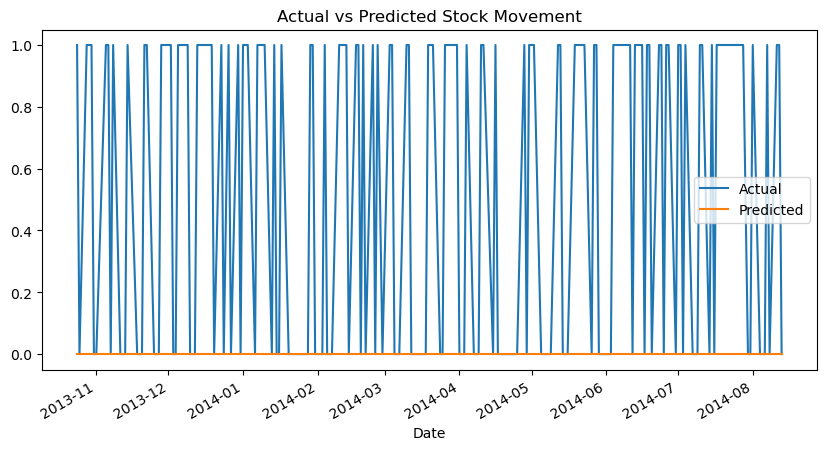

In [21]:
results[["Actual", "Predicted"]].iloc[:200].plot(figsize=(10,5))
plt.title("Actual vs Predicted Stock Movement")
plt.show()